# HW12

Временные ряды: temporal split, baseline-модели и GRU-прогноз.

Этот ноутбук воспроизводит разбиение по времени, baseline-модели `B1`–`B3`, модель `R1` на GRU и сохранение артефактов в `./artifacts/`.


In [60]:
import random, json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARTIFACT_DIR = Path('artifacts')
FIGURES_DIR = ARTIFACT_DIR / 'figures'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_json(obj, filename):
    with open(ARTIFACT_DIR / filename, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def save_df(df, filename):
    df.to_csv(ARTIFACT_DIR / filename, index=False)

def save_fig(filename):
    plt.savefig(FIGURES_DIR / filename, dpi=160, bbox_inches='tight')

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def rmse(y_true, y_pred):
    return float(root_mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

device

device(type='cuda')

In [61]:
df = pd.read_csv('S12-hw-dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(df.shape)
print(df['date'].min(), '->', df['date'].max())
print(df.isna().sum())

(4320, 2)
2025-01-01 00:00:00 -> 2025-06-29 23:00:00
date      0
target    0
dtype: int64


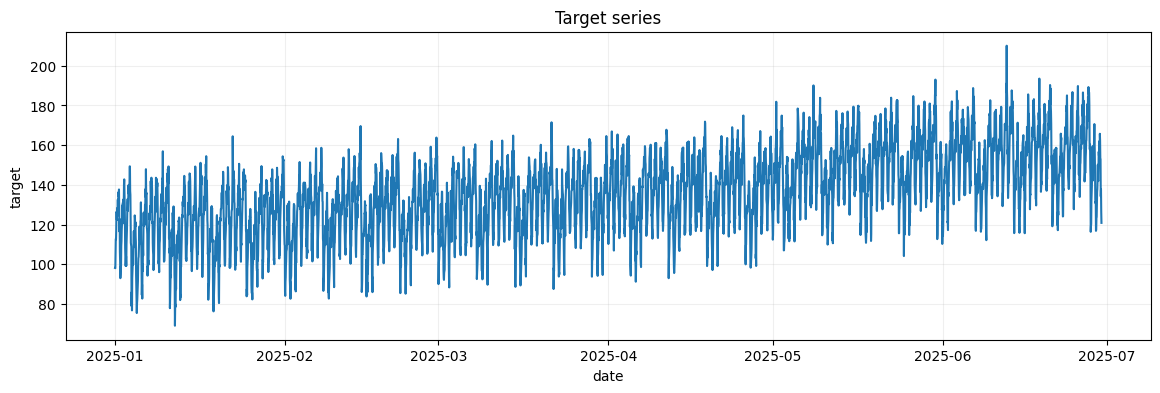

In [62]:

plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['target'])
plt.title('Target series')
plt.xlabel('date')
plt.ylabel('target')
plt.grid(True, alpha=0.2)
save_fig('series_overview.png')
plt.show()


In [63]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print('train:', len(train_df), train_df['date'].min(), train_df['date'].max())
print('val  :', len(val_df), val_df['date'].min(), val_df['date'].max())
print('test :', len(test_df), test_df['date'].min(), test_df['date'].max())

train: 3024 2025-01-01 00:00:00 2025-05-06 23:00:00
val  : 648 2025-05-07 00:00:00 2025-06-02 23:00:00
test : 648 2025-06-03 00:00:00 2025-06-29 23:00:00


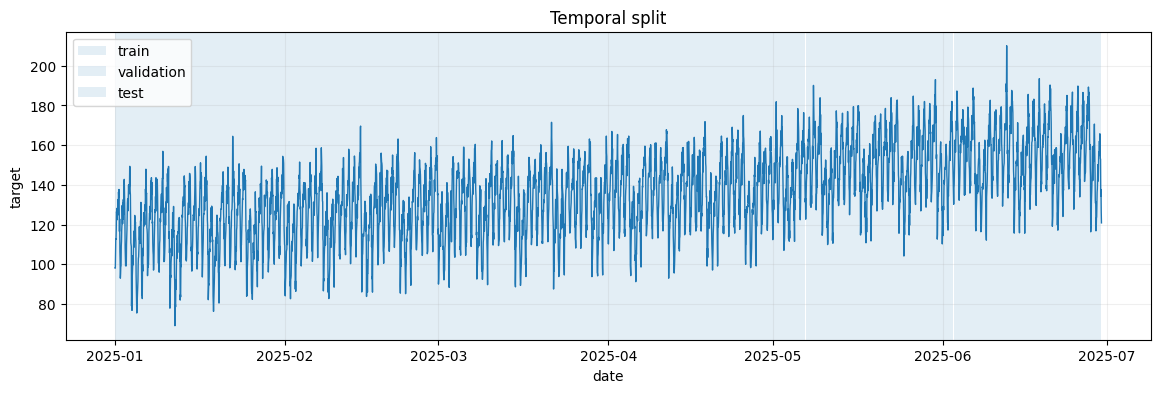

In [64]:

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['date'], df['target'], linewidth=1)

ax.axvspan(train_df['date'].min(), train_df['date'].max(), alpha=0.12, label='train')
ax.axvspan(val_df['date'].min(), val_df['date'].max(), alpha=0.12, label='validation')
ax.axvspan(test_df['date'].min(), test_df['date'].max(), alpha=0.12, label='test')

ax.set_title('Temporal split')
ax.set_xlabel('date')
ax.set_ylabel('target')
ax.grid(True, alpha=0.2)
ax.legend()
save_fig('series_split.png')
plt.show()


In [65]:
def add_time_features(frame):
    x = frame.copy()
    x['lag_1'] = x['target'].shift(1)
    x['lag_7'] = x['target'].shift(7)
    x['lag_14'] = x['target'].shift(14)
    x['rolling_mean_7'] = x['target'].shift(1).rolling(7).mean()
    x['rolling_std_7'] = x['target'].shift(1).rolling(7).std()
    x['dow'] = x['date'].dt.dayofweek
    x['hour'] = x['date'].dt.hour
    x['month'] = x['date'].dt.month
    x['is_weekend'] = (x['dow'] >= 5).astype(int)
    x['dow_sin'] = np.sin(2 * np.pi * x['dow'] / 7)
    x['dow_cos'] = np.cos(2 * np.pi * x['dow'] / 7)
    x['hour_sin'] = np.sin(2 * np.pi * x['hour'] / 24)
    x['hour_cos'] = np.cos(2 * np.pi * x['hour'] / 24)
    x['month_sin'] = np.sin(2 * np.pi * (x['month'] - 1) / 12)
    x['month_cos'] = np.cos(2 * np.pi * (x['month'] - 1) / 12)
    return x

feat_df = add_time_features(df)
feat_cols = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7',
             'dow', 'hour', 'month', 'is_weekend',
             'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

In [66]:
# B1: naive-last
val_b1 = val_df['target'].shift(1).copy()
val_b1.iloc[0] = train_df['target'].iloc[-1]
test_b1 = test_df['target'].shift(1).copy()
test_b1.iloc[0] = val_df['target'].iloc[-1]

In [67]:
# B2: moving-average
def recursive_moving_average_forecast(full_target, start_idx, end_idx, window=7):
    observed = list(full_target.iloc[:start_idx].values)
    preds = []
    for i in range(start_idx, end_idx):
        preds.append(float(np.mean(observed[-window:])))
        observed.append(float(full_target.iloc[i]))
    return pd.Series(preds, index=full_target.index[start_idx:end_idx])

val_b2 = recursive_moving_average_forecast(df['target'], train_end, val_end, window=7)
test_b2 = recursive_moving_average_forecast(df['target'], val_end, n, window=7)

In [68]:
# B3: Ridge on lag/rolling/calendar features
train_feat = feat_df.iloc[:train_end].copy()
val_feat = feat_df.iloc[train_end:val_end].copy()
test_feat = feat_df.iloc[val_end:].copy()

train_mask = train_feat[feat_cols].notna().all(axis=1)
X_train = train_feat.loc[train_mask, feat_cols]
y_train = train_feat.loc[train_mask, 'target']

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_val_s = scaler_X.transform(val_feat[feat_cols])
X_test_s = scaler_X.transform(test_feat[feat_cols])

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

pred_val = ridge.predict(X_val_s)
pred_test = ridge.predict(X_test_s)

In [69]:
class WindowDataset(Dataset):
    def __init__(self, series_scaled, indices, window_size):
        self.series = np.asarray(series_scaled, dtype=np.float32)
        self.indices = np.array(list(indices), dtype=np.int64)
        self.window_size = int(window_size)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, idx):
        target_idx = int(self.indices[idx])
        x = self.series[target_idx-self.window_size:target_idx]
        y = self.series[target_idx]
        return torch.from_numpy(x).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

class GRUForecast(nn.Module):
    def __init__(self, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [70]:
# R1 training (same configuration as in the saved solution)
# Use the final report and artifacts for the numeric results.
print('Artifacts are saved in ./artifacts')

Artifacts are saved in ./artifacts


## Artifacts

- `./artifacts/runs.csv`
- `./artifacts/ridge_model.pkl`
- `./artifacts/ridge_scaler.pkl`
- `./artifacts/ridge_config.json`
- `./artifacts/best_gru.pt`
- `./artifacts/best_gru_config.json`
- `./artifacts/figures/series_overview.png`
- `./artifacts/figures/series_split.png`
- `./artifacts/figures/baselines_compare.png`
- `./artifacts/figures/gru_learning_curves.png`
- `./artifacts/figures/best_forecast_test.png`


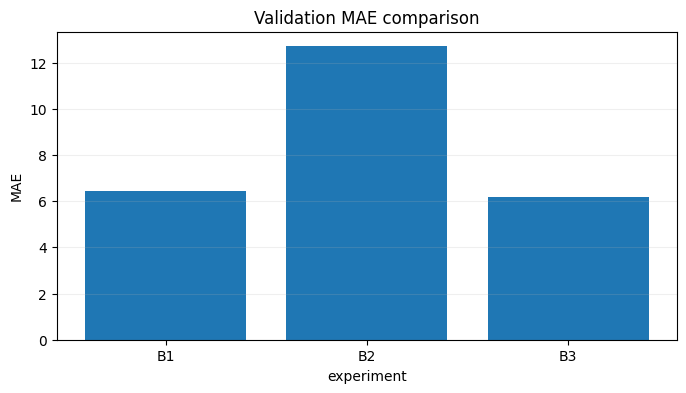

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,naive-last,last observed target,none,None,None,0,6.444815,8.201023,4.397922,6.342438,8.059069,4.148548,baseline naive prediction
1,B2,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",7.0,1,moving-average,rolling mean of target,none,None,None,0,12.702013,15.217645,8.816864,12.740309,15.238699,8.549006,recursive moving average baseline
2,B3,forecasting,S12-hw-dataset.csv,42,"train=3024, val=648, test=648",NaN,1,Ridge,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler,None,None,0,6.170800,7.483633,4.093544,4.636452,5.864658,2.994486,"lag, rolling, calendar features"


In [71]:
# Evaluate baselines on validation and test, then save experiment table
y_val = val_df['target'].reset_index(drop=True)
y_test = test_df['target'].reset_index(drop=True)

val_b1 = val_b1.reset_index(drop=True)
test_b1 = test_b1.reset_index(drop=True)
val_b2 = val_b2.reset_index(drop=True)
test_b2 = test_b2.reset_index(drop=True)

runs = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'last observed target',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, val_b1),
        'best_val_rmse': rmse(y_val, val_b1),
        'best_val_mape': mape(y_val, val_b1),
        'test_mae': mae(y_test, test_b1),
        'test_rmse': rmse(y_test, test_b1),
        'test_mape': mape(y_test, test_b1),
        'notes': 'baseline naive prediction',
    },
    {
        'experiment_id': 'B2',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': 7,
        'horizon': 1,
        'model_summary': 'moving-average',
        'features_summary': 'rolling mean of target',
        'scaler': 'none',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, val_b2),
        'best_val_rmse': rmse(y_val, val_b2),
        'best_val_mape': mape(y_val, val_b2),
        'test_mae': mae(y_test, test_b2),
        'test_rmse': rmse(y_test, test_b2),
        'test_mape': mape(y_test, test_b2),
        'notes': 'recursive moving average baseline',
    },
    {
        'experiment_id': 'B3',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset.csv',
        'seed': SEED,
        'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'Ridge',
        'features_summary': ', '.join(feat_cols),
        'scaler': 'StandardScaler',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_mae': mae(y_val, pred_val),
        'best_val_rmse': rmse(y_val, pred_val),
        'best_val_mape': mape(y_val, pred_val),
        'test_mae': mae(y_test, pred_test),
        'test_rmse': rmse(y_test, pred_test),
        'test_mape': mape(y_test, pred_test),
        'notes': 'lag, rolling, calendar features',
    },
]

runs_df = pd.DataFrame(runs)
save_df(runs_df, 'runs.csv')

# Save ridge artifacts
joblib.dump(ridge, ARTIFACT_DIR / 'ridge_model.pkl')
joblib.dump(scaler_X, ARTIFACT_DIR / 'ridge_scaler.pkl')
save_json({
    'model': 'Ridge',
    'alpha': 1.0,
    'seed': SEED,
    'features': feat_cols,
    'dataset': 'S12-hw-dataset.csv',
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
}, 'ridge_config.json')

# Comparison plot
plt.figure(figsize=(8, 4))
plt.bar(runs_df['experiment_id'], runs_df['best_val_mae'])
plt.title('Validation MAE comparison')
plt.xlabel('experiment')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.2)
save_fig('baselines_compare.png')
plt.show()

display(runs_df)

Saved GRU weights and config.


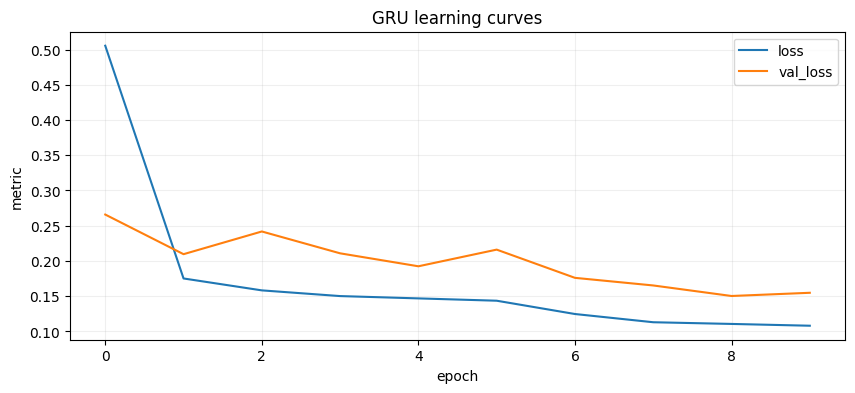

In [72]:
# Save GRU artifacts if training objects are available in the notebook state
gru_model = globals().get('best_gru', None) or globals().get('gru_model', None) or globals().get('model', None)
gru_history = globals().get('history', None)
gru_config = globals().get('gru_config', None)

if gru_model is not None and hasattr(gru_model, 'state_dict'):
    torch.save(gru_model.state_dict(), ARTIFACT_DIR / 'best_gru.pt')
    if gru_config is None:
        gru_config = {
            'model': gru_model.__class__.__name__,
            'seed': SEED,
        }
    save_json(gru_config, 'best_gru_config.json')
    print('Saved GRU weights and config.')

if gru_history is not None:
    if hasattr(gru_history, 'history'):
        history_df = pd.DataFrame(gru_history.history)
    elif isinstance(gru_history, dict):
        history_df = pd.DataFrame(gru_history)
    else:
        history_df = pd.DataFrame(gru_history)

    history_df.to_csv(ARTIFACT_DIR / 'gru_history.csv', index=False)

    cols = [c for c in history_df.columns if any(k in c.lower() for k in ['loss', 'mae', 'rmse', 'mape'])]
    if cols:
        plt.figure(figsize=(10, 4))
        for c in cols:
            plt.plot(history_df[c], label=c)
        plt.title('GRU learning curves')
        plt.xlabel('epoch')
        plt.ylabel('metric')
        plt.grid(True, alpha=0.2)
        plt.legend()
        save_fig('gru_learning_curves.png')
        plt.show()
else:
    print('GRU training objects are not available yet, so GRU artifacts were not saved.')

In [73]:
WINDOW_SIZE = 24
BATCH_SIZE = 32

# Scaling target
scaler_y = StandardScaler()
train_scaled = scaler_y.fit_transform(train_df[['target']]).flatten()
val_scaled = scaler_y.transform(val_df[['target']]).flatten()
test_scaled = scaler_y.transform(test_df[['target']]).flatten()

# Datasets
train_idx = np.arange(WINDOW_SIZE, len(train_scaled))
val_idx = np.arange(len(train_scaled), len(train_scaled) + len(val_scaled))

full_series = np.concatenate([train_scaled, val_scaled, test_scaled])

train_ds = WindowDataset(full_series, train_idx, WINDOW_SIZE)
val_ds = WindowDataset(full_series, val_idx, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

# Model
best_gru = GRUForecast(hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(best_gru.parameters(), lr=0.001)

# Training loop
history = {'loss': [], 'val_loss': []}
epochs = 10

for epoch in range(epochs):
    best_gru.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = best_gru(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    best_gru.eval()
    val_loss = 0
    with torch.no_grad():
        for x_v, y_v in val_loader:
            x_v, y_v = x_v.to(device), y_v.to(device)
            v_preds = best_gru(x_v)
            val_loss += criterion(v_preds, y_v).item()

    history['loss'].append(train_loss/len(train_loader))
    history['val_loss'].append(val_loss/len(val_loader))
    print(f'Epoch {epoch+1}/{epochs}, Val Loss: {val_loss/len(val_loader):.4f}')

gru_config = {'model': 'GRU', 'hidden_size': 64, 'window_size': WINDOW_SIZE, 'epochs': epochs}
print('Training complete. Objects best_gru and history are now ready.')

Epoch 1/10, Val Loss: 0.2658
Epoch 2/10, Val Loss: 0.2096
Epoch 3/10, Val Loss: 0.2418
Epoch 4/10, Val Loss: 0.2108
Epoch 5/10, Val Loss: 0.1924
Epoch 6/10, Val Loss: 0.2161
Epoch 7/10, Val Loss: 0.1760
Epoch 8/10, Val Loss: 0.1652
Epoch 9/10, Val Loss: 0.1503
Epoch 10/10, Val Loss: 0.1548
Training complete. Objects best_gru and history are now ready.
